<a href="https://colab.research.google.com/github/jellybbie/study/blob/pre-save/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

file_path = '/content/comb_saltstress1.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Type,Strain,repeat 1,repeat 2,repeat 3
0,Bacteria,1R-RH9-M1-A6,1.35,2.29,2.40
1,Bacteria,1R-RH9-M1-B2,1.58,2.78,3.81
2,Bacteria,1R-RH9-M1-B3,2.42,5.59,5.48
3,Bacteria,2R-RH6-M1-F5,5.47,4.83,5.44
4,Bacteria,2R-RH6-M1-F6,2.19,4.24,5.37


In [4]:
display(strain_stats)

,Type,Strain,Mean Repeat Value,Std Dev Repeat Value
0,Bacillus,2KL1,5.613333,2.227921
1,Bacillus,2KL2,4.656667,0.696156
2,Bacillus,2KL3,4.000000,0.671044
3,Bacillus,2RF,4.610000,1.481114
4,Bacillus,2RL1-1,3.596667,0.600528
...,...,...,...,...
244,Yeast,CNSJW2-4,4.870000,1.241652
245,Yeast,JAFC4-7,4.760000,1.261943
246,Yeast,MGLJW-15,5.323333,0.290230
247,Yeast,RJAFC2-5,3.850000,0.953467


/tmp/ipykernel_1102/4182042881.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Mean Repeat Value', data=strain_stats, palette='viridis')


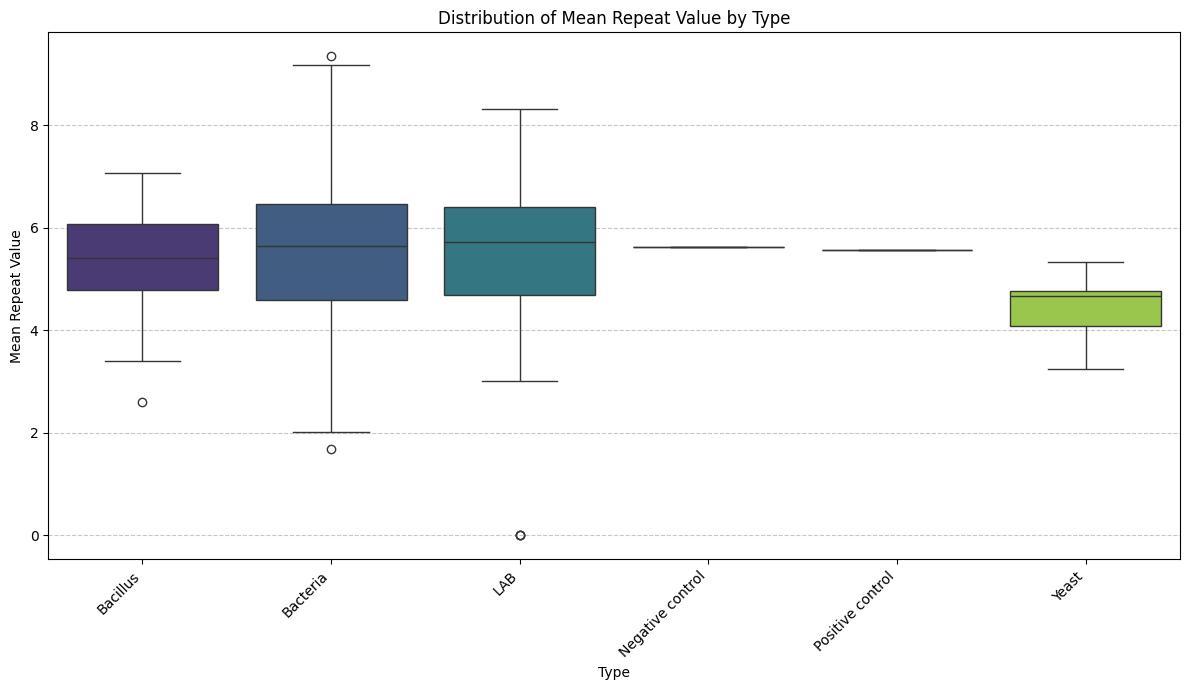

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='Type', y='Mean Repeat Value', data=strain_stats, palette='viridis')
plt.title('Distribution of Mean Repeat Value by Type')
plt.xlabel('Type')
plt.ylabel('Mean Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1102/834137309.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Mean Repeat Value', data=filtered_strain_stats, palette='viridis')


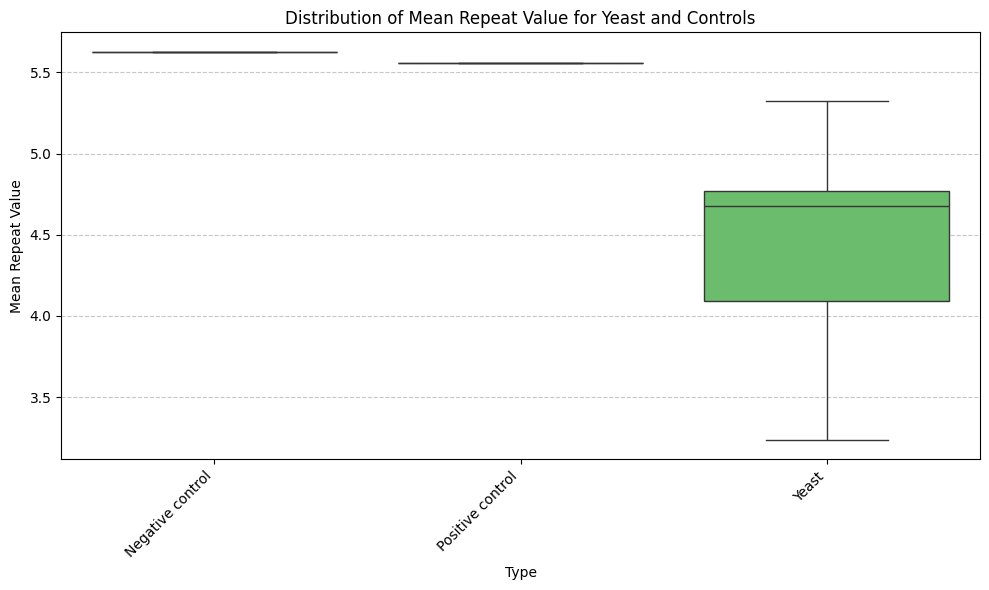

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the strain_stats DataFrame for the desired types
filtered_strain_stats = strain_stats[
    strain_stats['Type'].isin(['Yeast', 'Negative control', 'Positive control'])
]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Mean Repeat Value', data=filtered_strain_stats, palette='viridis')
plt.title('Distribution of Mean Repeat Value for Yeast and Controls')
plt.xlabel('Type')
plt.ylabel('Mean Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1102/644459038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strain', y='Mean Repeat Value', data=yeast_strain_stats, palette='viridis')


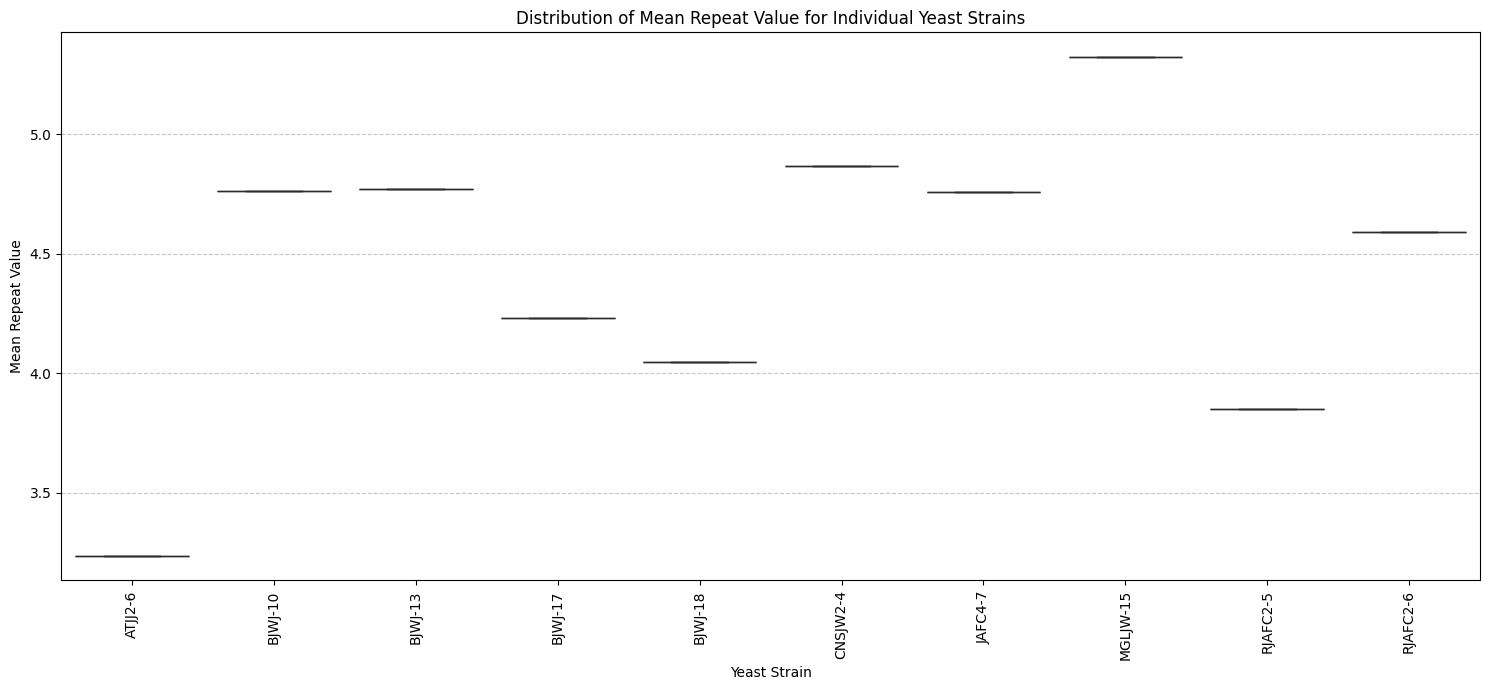

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the strain_stats DataFrame for 'Yeast' type only
yeast_strain_stats = strain_stats[strain_stats['Type'] == 'Yeast']

plt.figure(figsize=(15, 7))
sns.boxplot(x='Strain', y='Mean Repeat Value', data=yeast_strain_stats, palette='viridis')
plt.title('Distribution of Mean Repeat Value for Individual Yeast Strains')
plt.xlabel('Yeast Strain')
plt.ylabel('Mean Repeat Value')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

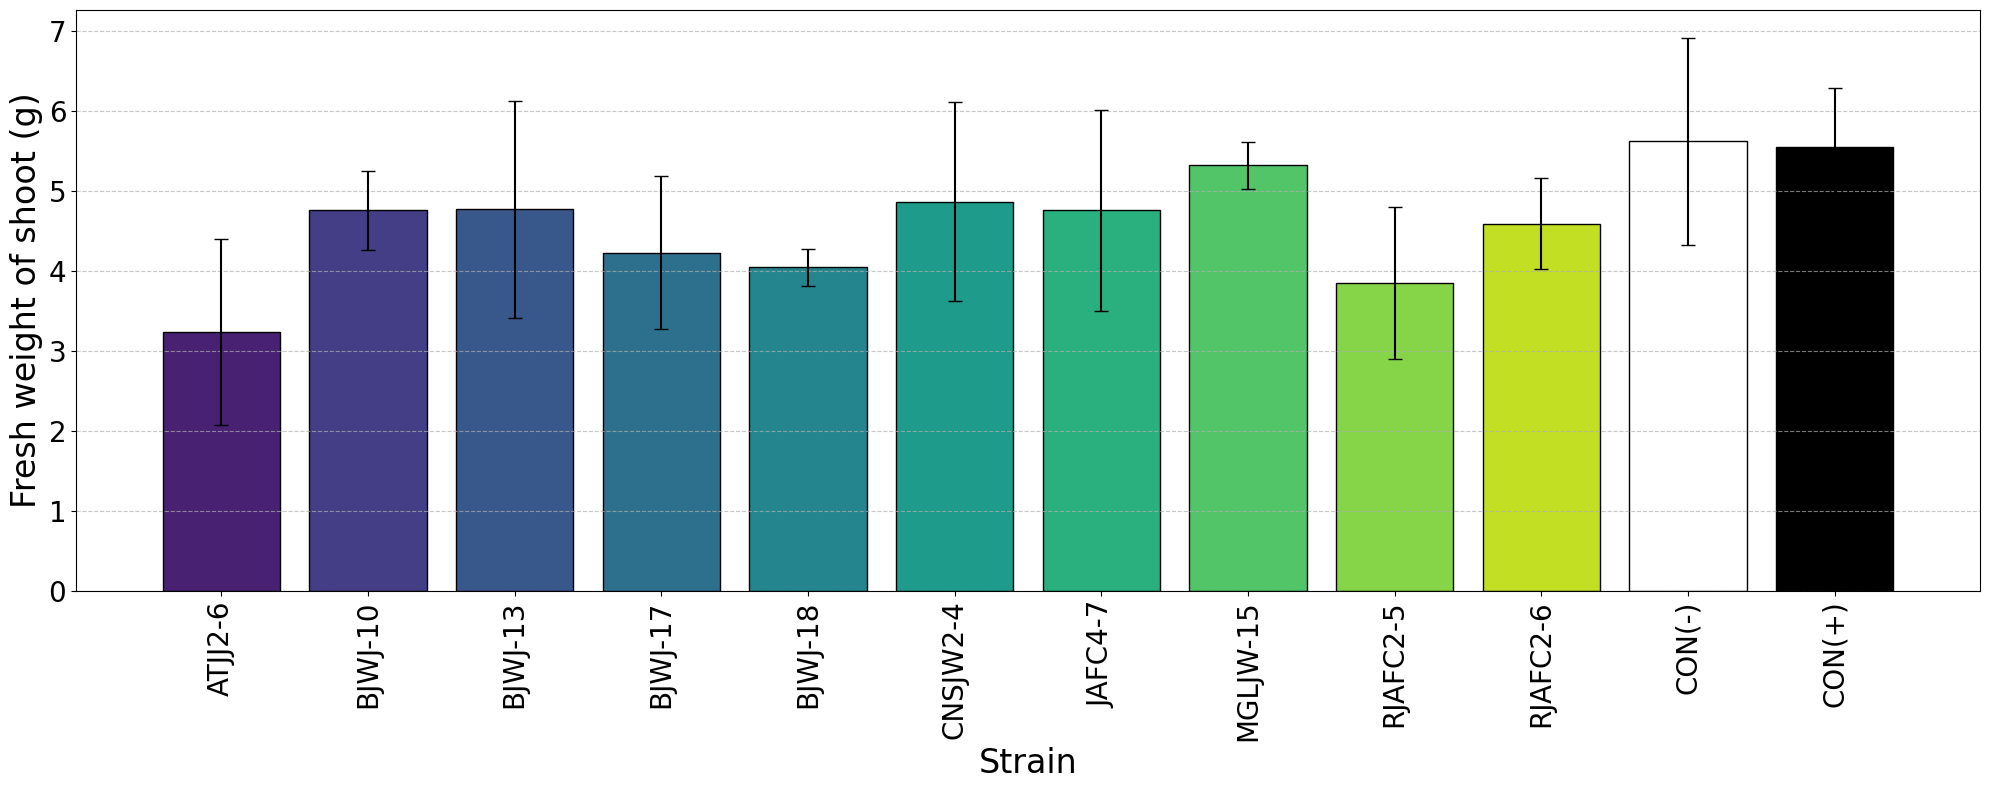

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# Filter for Yeast strains and controls from the main strain_stats DataFrame
yeast_and_controls_stats = strain_stats[
    strain_stats['Type'].isin(['Yeast', 'Negative control', 'Positive control'])
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Define the order for the x-axis: Yeast strains first, then Negative, then Positive control
yeast_strains_order = yeast_and_controls_stats[yeast_and_controls_stats['Type'] == 'Yeast']['Strain'].tolist()
x_axis_order = yeast_strains_order + ['CON(-)', 'CON(+)']

# Create a filtered DataFrame that respects the order for plotting
# This ensures that the data is sorted according to x_axis_order before plotting
ordered_data_for_plot = yeast_and_controls_stats.set_index('Strain').loc[x_axis_order].reset_index()

# Prepare custom colors for all strains and controls in the plot
color_map_plot = {}
default_colors = sns.color_palette('viridis', len(yeast_strains_order))
for i, strain in enumerate(x_axis_order):
    if strain == 'CON(-)':
        color_map_plot[strain] = 'white'
    elif strain == 'CON(+)':
        color_map_plot[strain] = 'black'
    else: # It's a Yeast strain
        color_map_plot[strain] = default_colors[yeast_strains_order.index(strain)]

# Get the list of colors in the correct order for plotting
colors_for_bars = [color_map_plot[strain] for strain in ordered_data_for_plot['Strain']]

plt.figure(figsize=(20, 8))

# Using plt.bar directly
plt.bar(
    x=ordered_data_for_plot['Strain'],
    height=ordered_data_for_plot['Mean Repeat Value'],
    yerr=ordered_data_for_plot['Std Dev Repeat Value'],
    capsize=5, # Add caps to the error bars
    color=colors_for_bars,
    edgecolor='black' # Add edge color for visibility
)

# Remove chart title
# plt.title('Mean Repeat Value for Yeast Strains and Controls with Error Bars', fontsize=16)
plt.xlabel('Strain', fontsize=24)
plt.ylabel('Fresh weight of shoot (g)', fontsize=24)
plt.xticks(rotation=90, fontsize=20) # Rotate x-axis labels for better readability and increase font size
plt.yticks(fontsize=20) # Increase y-axis tick label font size
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remove legend
# legend_patches = []
# for strain_name in ordered_data_for_plot['Strain'].unique():
#     legend_patches.append(mpatches.Patch(color=color_map_plot[strain_name], label=strain_name, edgecolor='black'))
# plt.legend(handles=legend_patches, title='Strain/Control', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off
plt.show()

In [21]:
def cohen_d(mean1, sd1, n1, mean2, sd2, n2):
    # Calculate pooled standard deviation
    pooled_sd = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2))
    # Calculate Cohen's d
    d = (mean1 - mean2) / pooled_sd
    return d

# Get negative control stats
neg_control_mean = strain_stats[strain_stats['Strain'] == 'CON(-)']['Mean Repeat Value'].iloc[0]
neg_control_sd = strain_stats[strain_stats['Strain'] == 'CON(-)']['Std Dev Repeat Value'].iloc[0]
neg_control_n = 3 # Assuming 3 repeats for each strain as per raw data

# Strains identified as significant with raw p-values (p < 0.05)
significant_raw_p_strains = [
    '4R-RH6-M1-E8',
    '5R-RH6-M1-F11',
    '4R-RH7-M1-E3',
    '5R-RH10-M1-F3'
]

cohens_d_values = {}

print("\nCohen's d (vs. Negative Control) for selected Bacteria strains:")
for strain in significant_raw_p_strains:
    strain_mean = strain_stats[strain_stats['Strain'] == strain]['Mean Repeat Value'].iloc[0]
    strain_sd = strain_stats[strain_stats['Strain'] == strain]['Std Dev Repeat Value'].iloc[0]
    strain_n = 3 # Assuming 3 repeats for each strain

    d_val = cohen_d(strain_mean, strain_sd, strain_n, neg_control_mean, neg_control_sd, neg_control_n)
    cohens_d_values[strain] = d_val
    print(f"  {strain}: Cohen's d = {d_val:.3f}")

# Store the cohens_d_values for potential future use in plotting
# This makes it available for the next plotting step if the user wants to annotate the graph with these values.



Cohen's d (vs. Negative Control) for selected Bacteria strains:
  4R-RH6-M1-E8: Cohen's d = 2.630
  5R-RH6-M1-F11: Cohen's d = 2.194
  4R-RH7-M1-E3: Cohen's d = 3.273
  5R-RH10-M1-F3: Cohen's d = 3.376


In [34]:
def plot_strain_bar_graph(df_all_stats, group_type, negative_control_name='CON(-)', positive_control_name='CON(+)',
                          significant_strains_dict=None, plot_title="", y_lim=None, fontsize_x=20):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.patches as mpatches

    # Filter for the specified group and controls from the main df_all_stats DataFrame
    filtered_stats = df_all_stats[
        df_all_stats['Type'].isin([group_type, 'Negative control', 'Positive control'])
    ].copy()

    # Define the order for the x-axis: strains of the group first, then Negative, then Positive control
    group_strains_order = filtered_stats[filtered_stats['Type'] == group_type]['Strain'].tolist()
    x_axis_order_with_controls = group_strains_order + [negative_control_name, positive_control_name]

    # Create a filtered DataFrame that respects the order for plotting
    ordered_data_for_plot = filtered_stats.set_index('Strain').loc[x_axis_order_with_controls].reset_index()

    # Prepare custom colors for all strains and controls in the plot
    color_map_plot = {}
    default_colors = sns.color_palette('viridis', len(group_strains_order))
    for i, strain in enumerate(x_axis_order_with_controls):
        if strain == negative_control_name:
            color_map_plot[strain] = 'white'
        elif strain == positive_control_name:
            color_map_plot[strain] = 'black'
        elif strain in group_strains_order: # It's a strain of the specified group
            color_map_plot[strain] = default_colors[group_strains_order.index(strain)]

    # Get the list of colors in the correct order for plotting
    colors_for_bars = [color_map_plot[strain] for strain in ordered_data_for_plot['Strain']]

    plt.figure(figsize=(25, 8)) # Adjust figure size

    # Using plt.bar directly
    bar_container = plt.bar(
        x=ordered_data_for_plot['Strain'],
        height=ordered_data_for_plot['Mean Repeat Value'],
        yerr=ordered_data_for_plot['Std Dev Repeat Value'],
        capsize=5, # Add caps to the error bars
        color=colors_for_bars,
        edgecolor='black'
    )

    # Annotate bars for specific significant strains with asterisks if significant_strains_dict is provided
    if significant_strains_dict:
        significant_strain_names = list(significant_strains_dict.keys())
        for i, bar in enumerate(bar_container):
            strain_name = ordered_data_for_plot['Strain'].iloc[i]
            if strain_name in significant_strain_names:
                height = bar.get_height()
                error_bar_height = ordered_data_for_plot['Std Dev Repeat Value'].iloc[i]
                asterisk_y_pos = height + error_bar_height + 0.1
                plt.text(bar.get_x() + bar.get_width() / 2,
                         asterisk_y_pos,
                         '*',
                         ha='center', va='bottom', fontsize=20, color='black')

    plt.title(plot_title, fontsize=16)
    plt.xlabel('Strain', fontsize=24)
    plt.ylabel('Fresh weight of shoot (g)', fontsize=24)
    plt.xticks(rotation=90, fontsize=fontsize_x)
    plt.yticks(fontsize=20)
    if y_lim:
        plt.ylim(y_lim)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [20]:
from scipy import stats
import numpy as np
from statsmodels.stats.multitest import multipletests

# Extract raw repeat values for Negative Control
negative_control_data = df[df['Strain'] == 'CON(-)'][['repeat 1', 'repeat 2', 'repeat 3']].values.flatten()

# Get a list of all unique Bacteria strains
bacteria_strains = df[df['Type'] == 'Bacteria']['Strain'].unique()

# Dictionary to store p-values
p_values = {}

# Perform t-tests for each bacteria strain against the negative control
for strain in bacteria_strains:
    bacteria_strain_data = df[df['Strain'] == strain][['repeat 1', 'repeat 2', 'repeat 3']].values.flatten()

    # Perform independent t-test (one-sided: bacteria > control)
    # The alternative='greater' tests if the mean of the first sample is greater than the mean of the second sample.
    t_stat, p_val = stats.ttest_ind(bacteria_strain_data, negative_control_data, equal_var=False, alternative='greater')
    p_values[strain] = p_val

# Convert p-values dictionary to a list for correction
p_values_list = list(p_values.values())
strain_names_list = list(p_values.keys())

# Apply Benjamini-Hochberg (FDR 5%) correction for multiple comparisons
reject, pvals_corrected_fdr, _, _ = multipletests(p_values_list, alpha=0.05, method='fdr_bh')

significant_strains_fdr = {}
for i, strain in enumerate(strain_names_list):
    if reject[i]:
        significant_strains_fdr[strain] = pvals_corrected_fdr[i]

print("Original p-values:")
for strain, p_val in p_values.items():
    print(f"  {strain}: {p_val:.4f}")

print("\nBenjamini-Hochberg Corrected p-values (FDR 5%):")
for i, strain in enumerate(strain_names_list):
    print(f"  {strain}: {pvals_corrected_fdr[i]:.4f}")

print("\nStrains significantly greater than Negative Control (p < 0.05 using Benjamini-Hochberg correction):")
if significant_strains_fdr:
    for strain, p_val in significant_strains_fdr.items():
        print(f"  {strain} (p = {p_val:.4f})")
else:
    print("  No strains found to be significantly greater using Benjamini-Hochberg correction.")

Original p-values:
  1R-RH9-M1-A6: 0.9872
  1R-RH9-M1-B2: 0.9783
  1R-RH9-M1-B3: 0.7841
  2R-RH6-M1-F5: 0.6665
  2R-RH6-M1-F6: 0.8839
  2R-RH6-M1-F8: 0.8550
  2R-RH7-M1-B7: 0.9493
  2R-RH8-M1-C4: 0.9500
  2R-RH9-M1-A10: 0.9081
  2R-RH9-M1-A7: 0.9844
  2R-RH9-M1-B3: 0.8368
  2R-RH9-M1-B9: 0.9880
  2R-RH9-M1-C12: 0.9376
  2R-RH9-M1-F3: 0.2222
  2R-RH9-M1-F5: 0.4612
  2R-RH9-M1-F6: 0.1444
  2R-RH9-M1-G10: 0.2170
  2R-RH9-M1-G8: 0.3661
  3R-RH6-M1-C9: 0.6667
  3R-RH6-M1-D12: 0.1573
  3R-RH6-M1-F1: 0.8183
  3R-RH8-M1-A5: 0.1058
  3R-RH8-M1-F10: 0.1238
  3R-RH8-M1-F3: 0.6042
  3R-RH9-M1-D4: 0.7676
  3R-RH9-M1-D6: 0.6793
  3R-RH9-M1-F8: 0.0980
  3R-RH9-M1-G8: 0.4104
  3R-RH9-M1-H11: 0.2482
  4R-RH6-M1-D3: 0.5323
  4R-RH6-M1-E8: 0.0222
  4R-RH7-M1-C7: 0.3706
  4R-RH7-M1-E2: 0.3837
  4R-RH7-M1-F5: 0.6087
  4R-RH8-M1-D2: 0.1377
  4R-RH9-M1-C4: 0.6074
  5R-RH10-M1-F4: 0.1451
  5R-RH10-M1-H7: 0.0604
  5R-RH6-M1-F11: 0.0312
  2R-RH9-M1-D11: 0.8309
  4R-RH7-M1-E3: 0.0188
  5R-RH10-M1-F3: 0.0095
  GI

In [15]:
bacteria_stats = strain_stats[strain_stats['Type'] == 'Bacteria']
display(bacteria_stats)

,Type,Strain,Mean Repeat Value,Std Dev Repeat Value
54,Bacteria,1R-RH9-M1-A6,2.013333,0.577090
55,Bacteria,1R-RH9-M1-B2,2.723333,1.116079
56,Bacteria,1R-RH9-M1-B3,4.496667,1.799287
57,Bacteria,2R-RH6-M1-F5,5.246667,0.361156
58,Bacteria,2R-RH6-M1-F6,3.933333,1.612028
59,Bacteria,2R-RH6-M1-F8,4.563333,0.186100
60,Bacteria,2R-RH7-M1-B7,3.183333,1.503540
61,Bacteria,2R-RH8-M1-C4,3.430000,1.226499
62,Bacteria,2R-RH9-M1-A10,4.123333,0.915114
63,Bacteria,2R-RH9-M1-A7,1.683333,0.215484


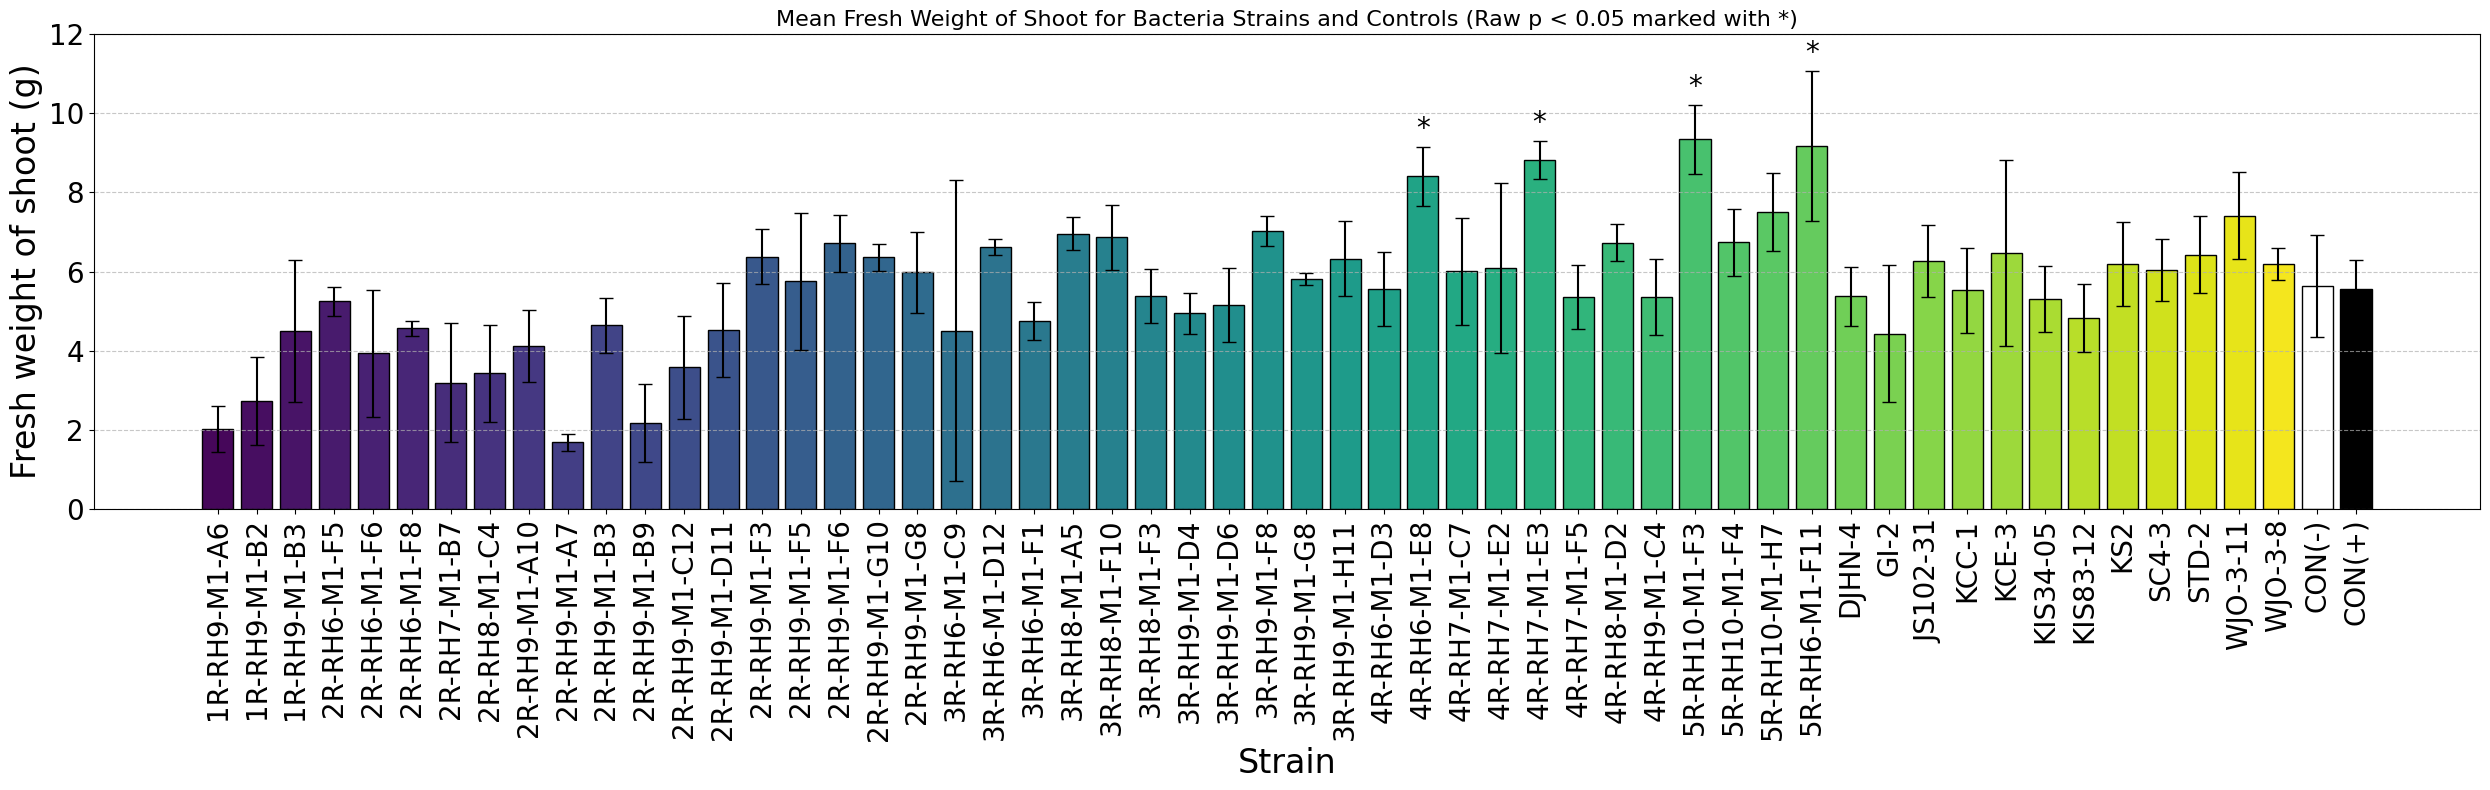

In [28]:
# Call the new function to plot the Bacteria group bar graph
plot_strain_bar_graph(
    df_all_stats=strain_stats,
    group_type='Bacteria',
    negative_control_name='CON(-)',
    positive_control_name='CON(+)',
    significant_strains_dict=significant_strains_raw, # Assuming significant_strains_raw is still available
    plot_title='Mean Fresh Weight of Shoot for Bacteria Strains and Controls (Raw p < 0.05 marked with *)',
    y_lim=(0, 12)
)

In [29]:
bacillus_stats = strain_stats[strain_stats['Type'] == 'Bacillus']
display(bacillus_stats)

,Type,Strain,Mean Repeat Value,Std Dev Repeat Value
0,Bacillus,2KL1,5.613333,2.227921
1,Bacillus,2KL2,4.656667,0.696156
2,Bacillus,2KL3,4.000000,0.671044
3,Bacillus,2RF,4.610000,1.481114
4,Bacillus,2RL1-1,3.596667,0.600528
5,Bacillus,2RL2-2,4.213333,0.590452
6,Bacillus,2RL2-3,3.393333,0.408207
7,Bacillus,2RL2-4,3.683333,0.531068
8,Bacillus,2RL3-1,4.796667,1.221324
9,Bacillus,2RL3-3,2.600000,0.310000


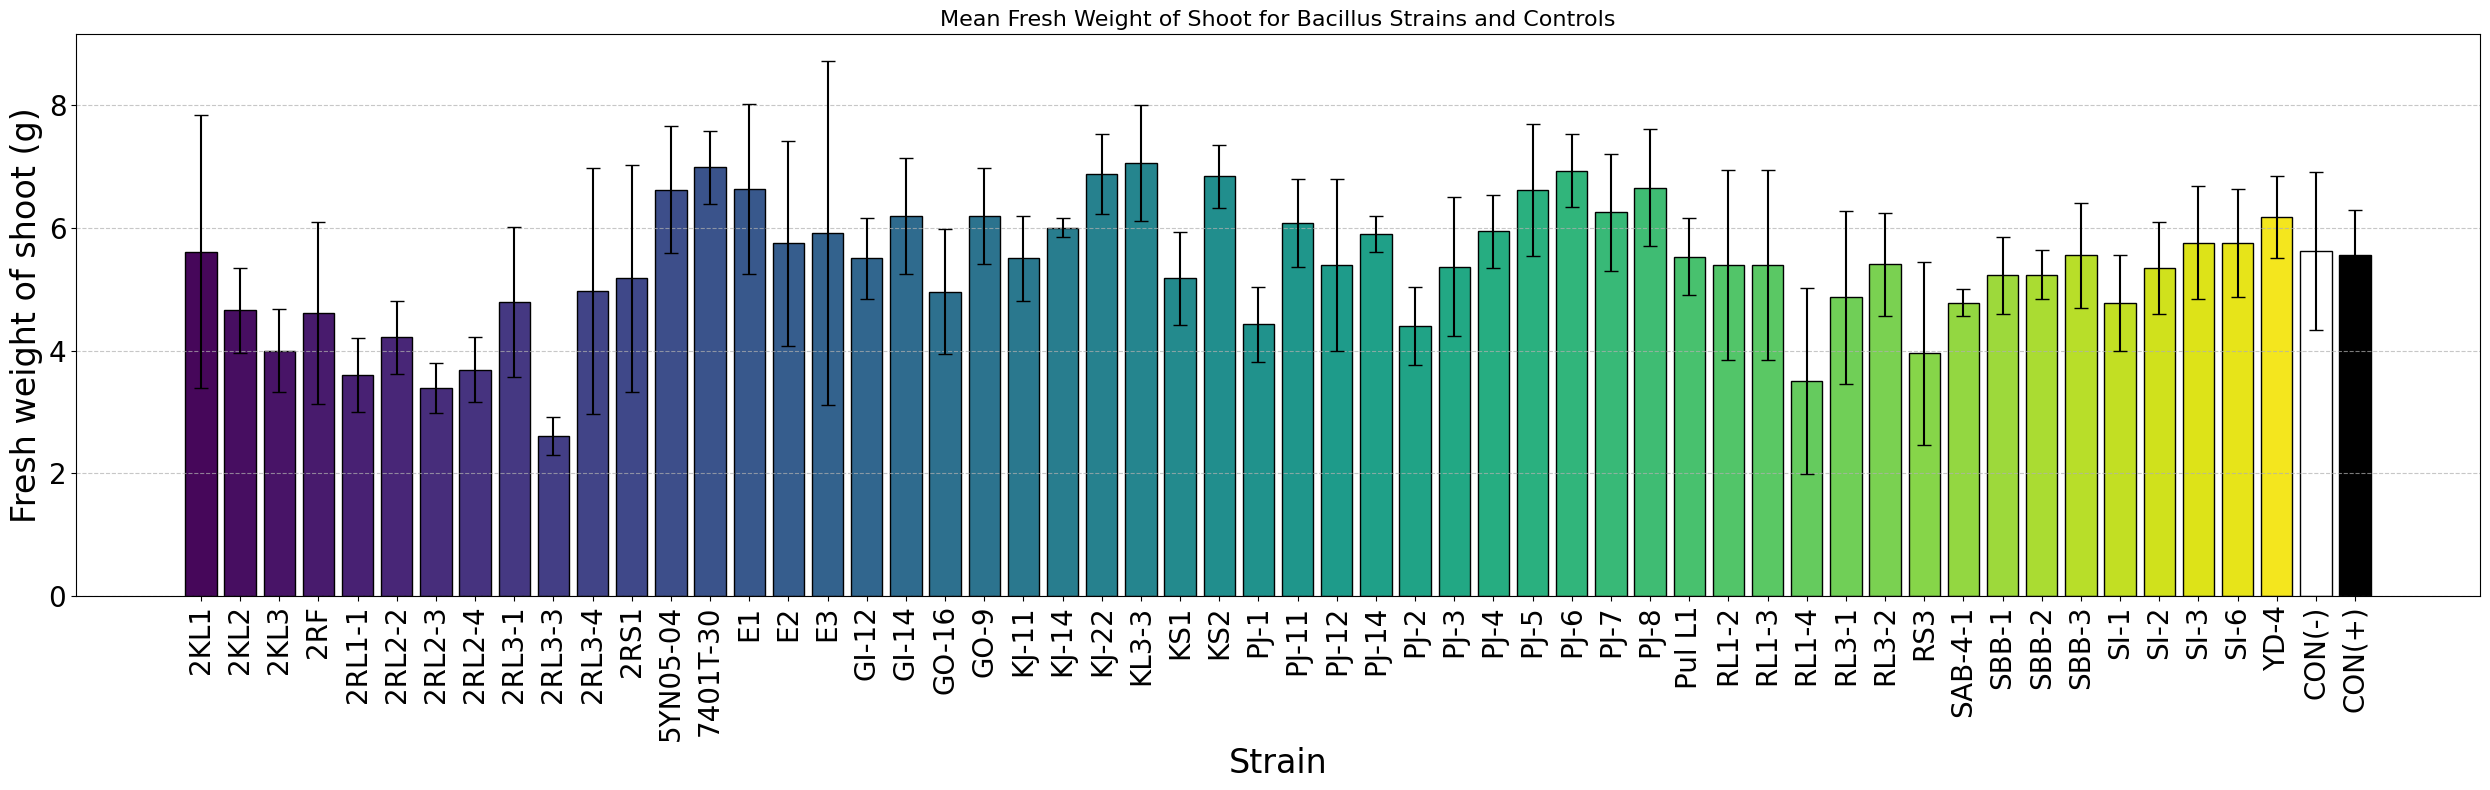

In [31]:
# Call the function to plot the Bacillus group bar graph
plot_strain_bar_graph(
    df_all_stats=strain_stats,
    group_type='Bacillus',
    negative_control_name='CON(-)',
    positive_control_name='CON(+)',
    plot_title='Mean Fresh Weight of Shoot for Bacillus Strains and Controls'
)

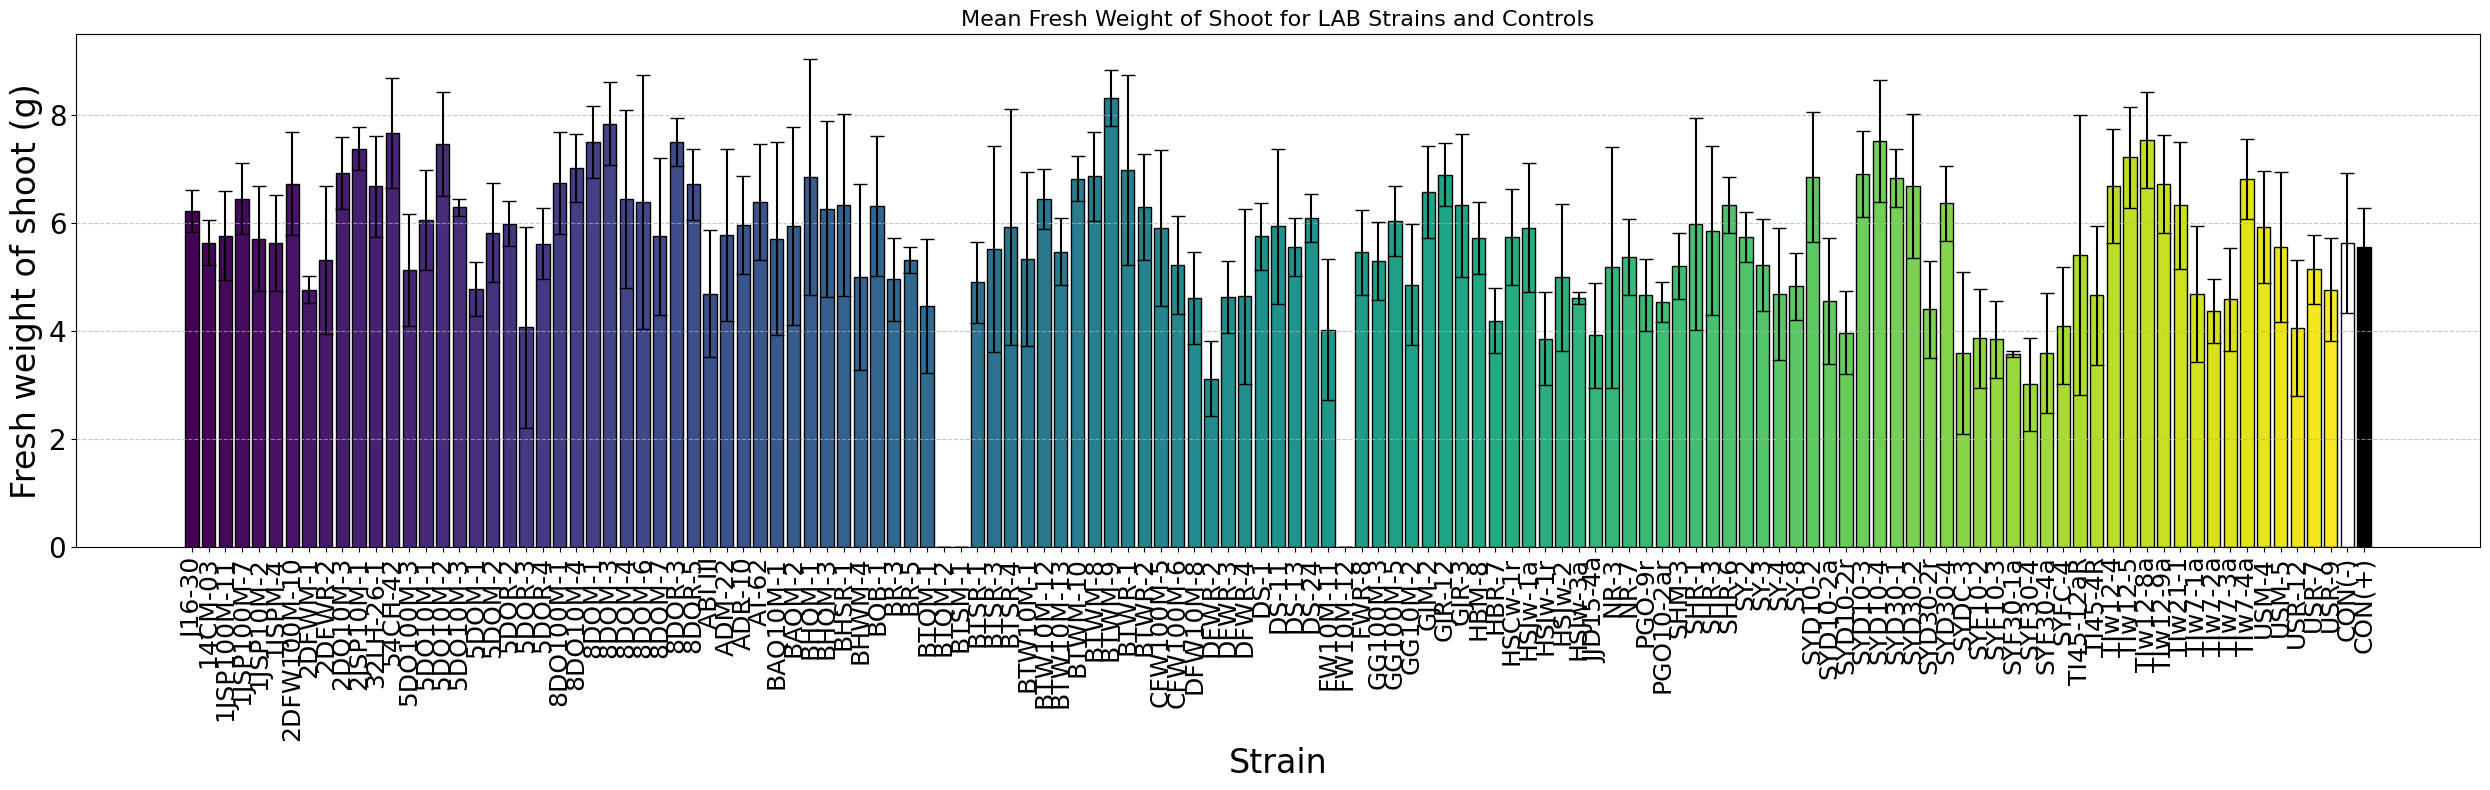

In [35]:
# Call the function to plot the LAB group bar graph
plot_strain_bar_graph(
    df_all_stats=strain_stats,
    group_type='LAB',
    negative_control_name='CON(-)',
    positive_control_name='CON(+)',
    plot_title='Mean Fresh Weight of Shoot for LAB Strains and Controls',
    fontsize_x=18
)

In [36]:
from scipy import stats
import numpy as np

# Extract raw repeat values for Negative Control (reusing existing variable if available, otherwise redefine)
# negative_control_data = df[df['Strain'] == 'CON(-)'][['repeat 1', 'repeat 2', 'repeat 3']].values.flatten()

# Get a list of all unique LAB strains
lab_strains = df[df['Type'] == 'LAB']['Strain'].unique()

# Dictionary to store p-values for LAB strains
p_values_lab = {}

# Perform t-tests for each LAB strain against the negative control
print("Performing one-sided t-tests for LAB strains vs. Negative Control...")
for strain in lab_strains:
    lab_strain_data = df[df['Strain'] == strain][['repeat 1', 'repeat 2', 'repeat 3']].values.flatten()

    # Perform independent t-test (one-sided: LAB > control)
    t_stat, p_val = stats.ttest_ind(lab_strain_data, negative_control_data, equal_var=False, alternative='greater')
    p_values_lab[strain] = p_val

# Identify significant strains with raw p-values < 0.05
significant_strains_lab_raw = {strain: p_val for strain, p_val in p_values_lab.items() if p_val < 0.05}

print("\nRaw p-values for LAB strains vs. Negative Control:")
for strain, p_val in p_values_lab.items():
    print(f"  {strain}: {p_val:.4f}")

print("\nLAB strains significantly greater than Negative Control (raw p < 0.05):")
if significant_strains_lab_raw:
    for strain, p_val in significant_strains_lab_raw.items():
        print(f"  {strain} (p = {p_val:.4f})")
else:
    print("  No LAB strains found to be significantly greater using raw p-values (p < 0.05).")

Performing one-sided t-tests for LAB strains vs. Negative Control...

Raw p-values for LAB strains vs. Negative Control:
  14CM-03: 0.4939
  54CH-42: 0.0513
  32LH-26-1: 0.1611
  BOB-1: 0.2736
  AT-62: 0.2391
   J16-30: 0.2580
  ABI III: 0.7960
  DS-1: 0.4415
  DS-11: 0.3956
  DS-13: 0.5299
  DS-24: 0.3024
  BR-3: 0.7514
  BR-5: 0.6410
  NR-3: 0.6078
  NR-7: 0.6061
  SY-2: 0.4486
  SY-3: 0.6593
  SY-4: 0.7932
  SY-8: 0.7947
  TI45-4R: 0.7932
  TI45-12aR: 0.5472
  TIw7-1a: 0.7905
  TIw7-2a: 0.8840
  TIw7-3a: 0.8347
  TIw7-4a: 0.1277
  TIw12-4: 0.1682
  TIw12-5: 0.0828
  TIw12-8a: 0.0560
  TIw12-9a: 0.1501
  TIw21-1: 0.2620
  SYD10-2: 0.1476
  SYD10-3: 0.1163
  SYD10-4: 0.0653
  SYD30-1: 0.1214
  SYD30-2: 0.1876
  SYD30-4: 0.2222
  SYDC-3: 0.9239
  SYF10-2: 0.9327
  SYF10-3: 0.9374
  SYF30-4: 0.9740
  SYFC-4: 0.9028
  SYD10-2r: 0.9270
  SYD30-2r: 0.8703
  SYD10-2a: 0.8252
  SYF30-1a: 0.9445
  SYF30-4a: 0.9448
  JJD15-4a: 0.9259
  PGO-9r: 0.8311
  PGO10-2ar: 0.8607
  HSJw-1a: 0.3936
  HSJ

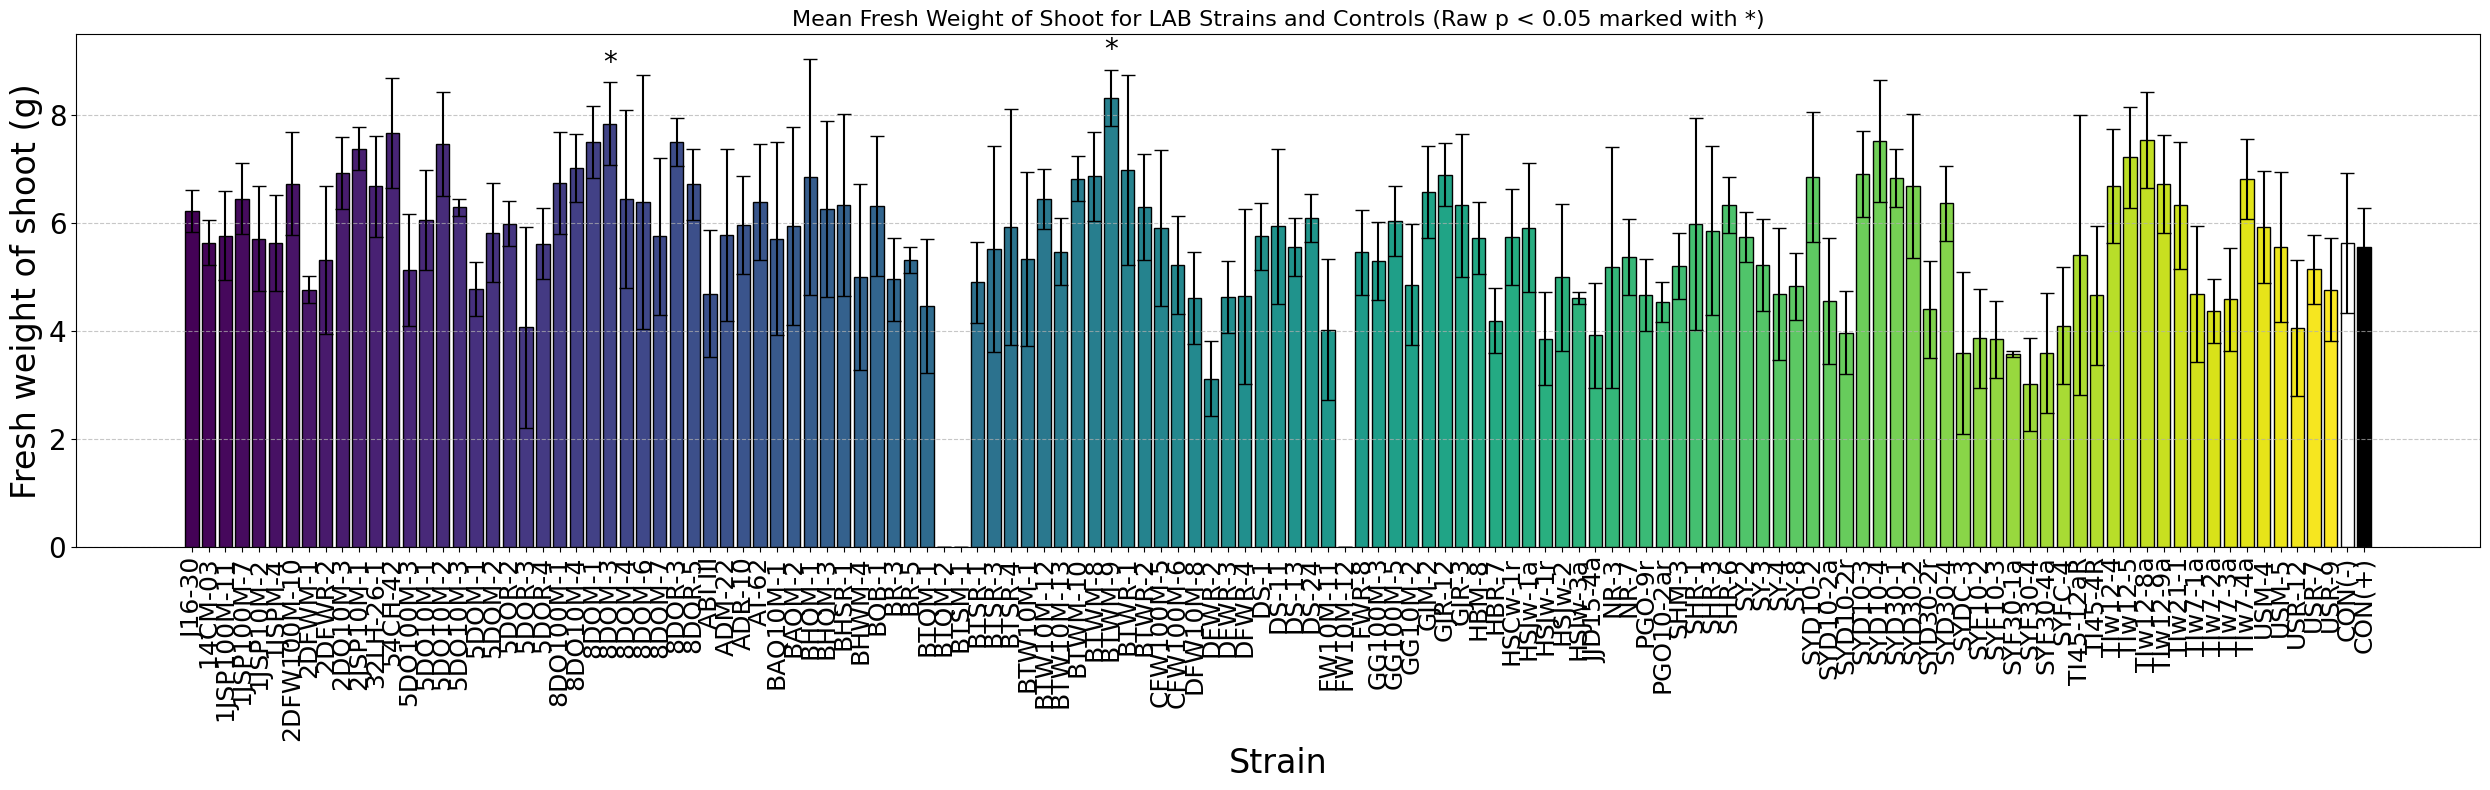

In [37]:
# Call the function to plot the LAB group bar graph, now with significant strains marked
plot_strain_bar_graph(
    df_all_stats=strain_stats,
    group_type='LAB',
    negative_control_name='CON(-)',
    positive_control_name='CON(+)',
    significant_strains_dict=significant_strains_lab_raw,
    plot_title='Mean Fresh Weight of Shoot for LAB Strains and Controls (Raw p < 0.05 marked with *)',
    fontsize_x=18
)

In [32]:
from scipy import stats
import numpy as np

# Extract raw repeat values for Negative Control (reusing existing variable if available, otherwise redefine)
# Assuming 'negative_control_data' is already defined from previous analysis, if not, it would be:
# negative_control_data = df[df['Strain'] == 'CON(-)'][['repeat 1', 'repeat 2', 'repeat 3']].values.flatten()

# Get a list of all unique Bacillus strains
bacillus_strains = df[df['Type'] == 'Bacillus']['Strain'].unique()

# Dictionary to store p-values for Bacillus strains
p_values_bacillus = {}

# Perform t-tests for each Bacillus strain against the negative control
print("Performing one-sided t-tests for Bacillus strains vs. Negative Control...")
for strain in bacillus_strains:
    bacillus_strain_data = df[df['Strain'] == strain][['repeat 1', 'repeat 2', 'repeat 3']].values.flatten()

    # Perform independent t-test (one-sided: bacteria > control)
    t_stat, p_val = stats.ttest_ind(bacillus_strain_data, negative_control_data, equal_var=False, alternative='greater')
    p_values_bacillus[strain] = p_val

# Identify significant strains with raw p-values < 0.05
significant_strains_bacillus_raw = {strain: p_val for strain, p_val in p_values_bacillus.items() if p_val < 0.05}

print("\nRaw p-values for Bacillus strains vs. Negative Control:")
for strain, p_val in p_values_bacillus.items():
    print(f"  {strain}: {p_val:.4f}")

print("\nBacillus strains significantly greater than Negative Control (raw p < 0.05):")
if significant_strains_bacillus_raw:
    for strain, p_val in significant_strains_bacillus_raw.items():
        print(f"  {strain} (p = {p_val:.4f})")
else:
    print("  No Bacillus strains found to be significantly greater using raw p-values (p < 0.05).")

Performing one-sided t-tests for Bacillus strains vs. Negative Control...

Raw p-values for Bacillus strains vs. Negative Control:
  GI-12: 0.5522
  GI-14: 0.2869
  GO-9: 0.2786
  GO-16: 0.7373
  YD-4: 0.2812
  KJ-11: 0.5519
  KJ-14: 0.3327
  KJ-22: 0.1158
  KL3-3: 0.1015
  KS1: 0.6801
  KS2: 0.1814
  RL1-2: 0.5733
  RL1-3: 0.5733
  RL1-4: 0.9295
  RL3-1: 0.7346
  RL3-2: 0.5891
  RS3: 0.8908
  2RF: 0.7889
  2RL1-1: 0.9520
  2RL2-2: 0.9047
  2RL2-3: 0.9575
  2RL2-4: 0.9467
  2RL3-1: 0.7676
  2RL3-3: 0.9754
  2RL3-4: 0.6689
  2RS1: 0.6252
  2KL1: 0.5033
  2KL2: 0.8327
  2KL3: 0.9256
  SAB-4-1: 0.8125
  SBB-1: 0.6676
  SBB-2: 0.6697
  SBB-3: 0.5303
  PJ-1: 0.8763
  PJ-2: 0.8795
  PJ-3: 0.5966
  PJ-4: 0.3639
  PJ-5: 0.1840
  PJ-6: 0.1079
  PJ-7: 0.2687
  PJ-8: 0.1665
  PJ-11: 0.3132
  PJ-12: 0.5753
  PJ-14: 0.3735
  Pul L1: 0.5410
  SI-1: 0.8016
  SI-2: 0.6143
  SI-3: 0.4448
  SI-6: 0.4481
  E1: 0.2059
  E2: 0.4614
  E3: 0.4402
  5YN05-04: 0.1794
  7401T-30: 0.1011

Bacillus strains signif

### Cohen's d Values for Significant Strains (vs. Negative Control)

In [26]:
import pandas as pd

# Assuming cohens_d_values is available from a previous cell's execution
cohens_d_df = pd.DataFrame(cohens_d_values.items(), columns=['Strain', 'Cohen\'s d'])
display(cohens_d_df)

,Strain,Cohen's d
0,4R-RH6-M1-E8,2.630457
1,5R-RH6-M1-F11,2.193555
2,4R-RH7-M1-E3,3.272926
3,5R-RH10-M1-F3,3.376231
